In [1]:
import sys
sys.path.insert(0, "/home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10")
import subprocess

import classy
print("classy imported from: \n",classy.__file__)
# import necessary modules
# uncomment to get plots displayed in notebook
import numpy as np
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from scipy.interpolate import interp2d
import os
import math
from scipy.interpolate import UnivariateSpline
import csv

basedir = os.path.abspath('./')
gdmdir = os.path.join(basedir,'gdm_files')

gdm_exists = os.path.exists('./gdm_files')

if gdm_exists :
     print('gdm exists')
#    subprocess.run(["rm","-r","gdm_files"])
#    subprocess.run(["mkdir","gdm_files"])
else :
    subprocess.run(["mkdir","gdm_files"])

#############################################
#
# # Cosmological parameters:
# z_max_pk = 5e7       # highest redshift involved
# z_max_rec = 1e6
# k_per_decade =250     # number of k values, controls final resolution
# k_min_tau0 = 0.1       # this value controls the minimum k value in the figure (it is k_min * tau0)
# P_k_max_inv_Mpc =5   # this value is directly the maximum k value in the figure in Mpc
# tau_num_early = 4200   # number of conformal time values before recombination, controls final resolution
# tau_num_late = 250     # number of conformal time values after recombination, controls final resolution
# tau_ini = 0.01          # first value of conformal time in Mpc
# #tau_label_Hubble = 20. # value of time at which we want to place the label on Hubble crossing
# #tau_label_ks = 40.     # value of time at which we want to place the label on sound horizon crossing
# #tau_label_kd = 230.    # value of time at which we want to place the label on damping scale crossing

# # Cosmological parameters:
# a_ini_over_a_today_default = 1e-14
# z_max_pk = 1e10       # highest redshift involved
# z_max_thermo = 5e7
# start_tau_k = 0.00001
# k_per_decade = 250     # number of k values, controls final resolution
# k_min_tau0 = .001       # this value controls the minimum k value in the figure (it is k_min * tau0)
# P_k_max_inv_Mpc =5   # this value is directly the maximum k value in the figure in Mpc
# tau_num_early = 1000   # number of conformal time values before recombination, controls final resolution
# tau_num_late = 500     # number of conformal time values after recombination, controls final resolution
#                         # first value of conformal time in Mpc
# h = 0.6732117

# Cosmological parameters:
z_max_pk = 5e7       # highest redshift involved
z_max_rec = 1e6
k_per_decade =250     # number of k values, controls final resolution
k_min_tau0 = 0.1       # this value controls the minimum k value in the figure (it is k_min * tau0)
P_k_max_inv_Mpc =5   # this value is directly the maximum k value in the figure in Mpc
tau_num_early = 4200   # number of conformal time values before recombination, controls final resolution
tau_num_late = 250     # number of conformal time values after recombination, controls final resolution
tau_ini = 0.01          # first value of conformal time in Mpc
#tau_label_Hubble = 20. # value of time at which we want to place the label on Hubble crossing
#tau_label_ks = 40.     # value of time at which we want to place the label on sound horizon crossing
#tau_label_kd = 230.    # value of time at which we want to place the label on damping scale crossing
h = 0.6732117

# Cosmological parameters:
# a_ini_over_a_today_default = 1e-14
# z_max_pk = 1e10       # highest redshift involved
# z_max_thermo = 5e7
# start_tau_k = 0.00001
# k_per_decade = 250     # number of k values, controls final resolution
# k_min_tau0 = .001       # this value controls the minimum k value in the figure (it is k_min * tau0)
# P_k_max_inv_Mpc =5   # this value is directly the maximum k value in the figure in Mpc
# tau_num_early = 1000   # number of conformal time values before recombination, controls final resolution
# tau_num_late = 500     # number of conformal time values after recombination, controls final resolution
#                         # first value of conformal time in Mpc
# h = 0.7184324

classy imported from: 
 /home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10/classy.cpython-310-x86_64-linux-gnu.so
gdm exists


In [ ]:
def get_sound_speeds(h, frac_dmde, g_scf, m_scf, phi_scf_ini): #(0.6732117, 0.4, 0.5, 0.1)
    common_settings = {# which output? transfer functions only
                   'output':'mTk',
                   # LambdaCDM parameters
                   'h':h,
                   'omega_b':0.022032,
                   'omega_cdm':0.1201075,
                   'frac_dmde': frac_dmde,
                   'g_scf': g_scf,
                   'm_scf': m_scf,
                   'phi_scf_ini': phi_scf_ini,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'Omega_k': 0.,
                   'A_s': 2.215e-9,
                  'n_s': 0.9619,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.245,
                   # other output and precision parameters
                   'z_max_pk':z_max_pk,
                   # to get a larger z_max in recfast, 
                   # we must increase both recfast_z_initial 
                   # and the number of sampled values recfast_Nz0
                   # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
                    'recfast_Nz0':z_max_rec*2.,
                    'recfast_z_initial':z_max_rec,
                   #'k_step_sub':'0.01',
                    'k_per_decade_for_pk':k_per_decade,
                    'k_per_decade_for_bao':k_per_decade,
                   'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
                #    'perturb_sampling_stepsize':'0.005',
                   'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                   #'compute damping scale':'yes', # needed to output and plot Silk damping scale
                   'gauge':'synchronous'}

    ###############
    #
    # call CLASS
    #
    ###############
    # print("Starting CLASS\n")

    M_pre = Class()
    M_pre.set(common_settings)
    M_pre.compute()

    # print("CLASS is done!\n")

    background = M_pre.get_background() # load background table                                                                                                                           
    #print background.viewkeys()                                                                                                                                                          
    background_tau = background['conf. time [Mpc]'] # read conformal times in background table       
    background_z = background['z'] # read redshift
    background_tau_at_z = interp1d(background_z,background_tau)

    tau_ini = background_tau_at_z(z_max_pk)
    # print(tau_ini)
    times = M_pre.get_current_derived_parameters(['tau_rec','conformal_age'])
    tau_rec=times['tau_rec']
    tau_0 = times['conformal_age']
    tau1 = np.logspace(math.log10(tau_ini),math.log10(5*tau_rec),tau_num_early)
    tau2 = np.logspace(math.log10(5*tau_rec),math.log10(tau_0),tau_num_late)[1:]
    tau2[-1]=tau_0
    tau2[-1] *= 0.999999 # this tiny shift avoids interpolation errors
    tau= np.concatenate((tau1,tau2))
    tau_num = len(tau)

    background_z = background['z'] # read redshift
    background_aH = background['H [1/Mpc]']/(1.+background['z'])

    background_rho_cdm = background['(.)rho_cdm'] # read rho cdm in background table
    background_rho_nu = background['(.)rho_ur'] # read rho nu in background table

    background_z_at_tau = interp1d(background_tau,background_z)
    a_tau = 1/(1+background_z_at_tau(tau))

    background_aH_at_a = interp1d(1/(background_z+1),background_aH)
    background_aH_at_tau = interp1d(background_tau,background_aH)
    background_a_at_tau = interp1d(background_tau,1/(background_z+1))

    background_rho_cdm_tau = interp1d(background_tau,background_rho_cdm)
    background_rho_nu_tau = interp1d(background_tau,background_rho_nu)

    background_rho_phi = background['(.)rho_scf']
    background_p_phi = background['(.)p_scf']
    background_rho_phi_tau = interp1d(background_tau,background_rho_phi)
    background_p_phi_tau = interp1d(background_tau,background_p_phi)

    background_rho_ncdm = background['(.)rho_ncdm[0]']
    background_rho_ncdm_tau = interp1d(background_tau,background_rho_ncdm)
    background_p_ncdm = background['(.)p_ncdm[0]']
    background_p_ncdm_tau = interp1d(background_tau,background_p_ncdm)

    # w_T_ncdm = background_p_ncdm/background_rho_ncdm
    # w_T_phi = background_p_phi/background_rho_phi
    w_T_general = (1/3*background_rho_nu+background_p_phi+background_p_ncdm)/(background_rho_cdm+background_rho_nu+background_rho_phi+background_rho_ncdm)
    # w_T_general = (1/3*background_rho_nu+background_p_phi)/(background_rho_cdm+background_rho_nu+background_rho_phi)

    w_T_at_a_interp = interp1d(1/(1+background_z),w_T_general)
    w_T_at_a_list = w_T_at_a_interp(a_tau)

    w_T_at_a_prime_interp = UnivariateSpline(1/(1+background_z),w_T_general,s=0).derivative()
    w_T_at_a_prime_list = w_T_at_a_prime_interp(a_tau)

    w_ncdm_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_ncdm/background_rho_ncdm,s=0)
    w_ncdm_at_a_list = w_ncdm_at_a_interp(a_tau)
    w_ncdm_at_a_prime_interp = w_ncdm_at_a_interp.derivative()
    w_ncdm_at_a_prime_list = w_ncdm_at_a_prime_interp(a_tau)
    p_ncdm_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_ncdm,s=0)
    p_ncdm_at_a_list = p_ncdm_at_a_interp(a_tau)

    p_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_phi,s=0)
    p_phi_at_a_list = p_phi_at_a_interp(a_tau)
    rho_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_rho_phi,s=0)
    rho_phi_at_a_list = rho_phi_at_a_interp(a_tau)
    w_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_phi/background_rho_phi,s=0)
    w_phi_at_a_list = w_phi_at_a_interp(a_tau)


    ones = np.ones(len(background_z))   
    ca2_list = w_T_at_a_interp(1/(1+background_z)) - 1./3.*1/(1+background_z)*w_T_at_a_prime_interp(1/(1+background_z))/(ones+w_T_at_a_interp(1/(1+background_z)))
    ca2_a = interp1d(1/(1+background_z),ca2_list)

    ones = np.ones(len(a_tau))
    ca2_list = w_T_at_a_list - 1./3.*a_tau*w_T_at_a_prime_list/(1+w_T_at_a_list)
    ca2_tau = interp1d(tau,ca2_list)

    w_T_tau = interp1d(background_tau,w_T_general)

    # print(background_z_at_tau(tau[0]))
    # print("Computing the perturbations\n")
    one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
    k = one_time['k (h/Mpc)']
    k_num = len(k)

    cs2_d = np.zeros((tau_num,k_num))
    delta_d = np.zeros((tau_num,k_num))
    theta_d = np.zeros((tau_num,k_num))
    c2eff_d = np.zeros((tau_num,k_num))
    Dc2_d = np.zeros((tau_num,k_num))

    for i in range(tau_num):
        one_time = M_pre.get_transfer(background_z_at_tau(tau[i]))
        
        delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]) + one_time['d_ncdm[0]'][:]*background_rho_ncdm_tau(tau[i]))\
        /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i])+background_rho_ncdm_tau(tau[i]))
        
        cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i])+one_time['d_ncdm[0]'][:]*background_p_ncdm_tau(tau[i]))\
                /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:]+background_rho_ncdm_tau(tau[i])*one_time['d_ncdm[0]'][:])
        
        # delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]))\
        # /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i]))
        
        # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i]))\
        #         /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:])
        
        # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i]))\
        #          /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:])
        
    
    common_settings = {# which output? transfer functions only
                   'output':'vTk',
                   # LambdaCDM parameters
                   'h':h,
                   'omega_b':0.022032,
                   'omega_cdm':0.1201075,
                   'frac_dmde': frac_dmde,
                   'g_scf': g_scf,
                   'm_scf': m_scf,
                   'phi_scf_ini': phi_scf_ini,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'Omega_k': 0.,
                   'A_s': 2.215e-9,
                  'n_s': 0.9619,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.245,
                   # other output and precision parameters
                   'z_max_pk':z_max_pk,
                   # to get a larger z_max in recfast, 
                   # we must increase both recfast_z_initial 
                   # and the number of sampled values recfast_Nz0
                   # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
                    'recfast_Nz0':z_max_rec*2.,
                    'recfast_z_initial':z_max_rec,
                   #'k_step_sub':'0.01',
                    'k_per_decade_for_pk':k_per_decade,
                    'k_per_decade_for_bao':k_per_decade,
                   'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
                #    'perturb_sampling_stepsize':'0.005',
                   'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                   #'compute damping scale':'yes', # needed to output and plot Silk damping scale
                   'gauge':'synchronous'}

    M_pre = Class()
    M_pre.set(common_settings)
    M_pre.compute()

    one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
    k = one_time['k (h/Mpc)']
    k_num = len(k)

    for i in range(tau_num):
        one_time = M_pre.get_transfer(background_z_at_tau(tau[i])) # transfer functions at each time tau

        theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list[i])*one_time['t__scf'][:]*background_rho_phi_tau(tau[i])+(1+w_ncdm_at_a_list[i])*one_time['t_ncdm[0]']*background_rho_ncdm_tau(tau[i]))\
        /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list[i])*background_rho_phi_tau(tau[i])+(1+w_ncdm_at_a_list[i])*background_rho_ncdm_tau(tau[i]))

        # theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list(i))*one_time['t__scf'][:]*background_rho_phi_tau(tau[i]))\
        # /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list(i))*background_rho_phi_tau(tau[i]))
        
        c2eff_d[i,:] = ((k*h)**2*cs2_d[i,:]*delta_d[i,:]+3*background_aH_at_tau(tau[i])*ca2_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])\
        /((k*h)**2*delta_d[i,:]+3*background_aH_at_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])
        Dc2_d[i,:] = c2eff_d[i,:]-ca2_tau(tau[i])
    
    return k, a_tau, w_T_at_a_list, w_T_at_a_prime_list, c2eff_d

In [3]:
# def get_sound_speeds(h, omega_b, omega_cdm, omega_k, YHe): #(0.6732117, 0.0223828, 0.1201075, 0., 0.245)
#     common_settings = {# which output? transfer functions only
#                    'output':'mTk',
#                    # LambdaCDM parameters
#                    'h':h,
#                    'omega_b':omega_b,
#                    'omega_cdm':omega_cdm,
#                    'frac_dmde': 0.6,
#                    'g_scf': 0.8,
#                    'm_scf': 0.2,
#                     # 'N_ncdm':1.,
#                     # 'omega_ncdm':0.39,
#                 #    'Omega_EDE':0.2,
#                    'Omega_k': omega_k,
#                    # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
#                    'YHe':YHe,
#                    # other output and precision parameters
#                    'z_max_pk':z_max_pk,
#                    # to get a larger z_max in recfast, 
#                    # we must increase both recfast_z_initial 
#                    # and the number of sampled values recfast_Nz0
#                    # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
#                    'recfast_Nz0':z_max_rec*2.,
#                    'recfast_z_initial':z_max_rec,
#                    #'k_step_sub':'0.01',
#                    'k_per_decade_for_pk':k_per_decade,
#                    'k_per_decade_for_bao':k_per_decade,
#                    'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
#                    'perturb_sampling_stepsize':'0.005',
#                    'P_k_max_1/Mpc':P_k_max_inv_Mpc,
#                    #'compute damping scale':'yes', # needed to output and plot Silk damping scale
#                    'gauge':'synchronous'}

#     ###############
#     #
#     # call CLASS
#     #
#     ###############
#     print("Starting CLASS\n")

#     M_pre = Class()
#     M_pre.set(common_settings)
#     M_pre.compute()

#     print("CLASS is done!\n")

#     background = M_pre.get_background() # load background table                                                                                                                           
#     #print background.viewkeys()                                                                                                                                                          
#     background_tau = background['conf. time [Mpc]'] # read conformal times in background table       
#     background_z = background['z'] # read redshift
#     background_tau_at_z = interp1d(background_z,background_tau)

#     tau_ini = background_tau_at_z(z_max_pk)
#     print(tau_ini)
#     times = M_pre.get_current_derived_parameters(['tau_rec','conformal_age'])
#     tau_rec=times['tau_rec']
#     tau_0 = times['conformal_age']
#     tau1 = np.logspace(math.log10(tau_ini),math.log10(5*tau_rec),tau_num_early)
#     tau2 = np.logspace(math.log10(5*tau_rec),math.log10(tau_0),tau_num_late)[1:]
#     tau2[-1]=tau_0
#     tau2[-1] *= 0.999999 # this tiny shift avoids interpolation errors
#     tau= np.concatenate((tau1,tau2))
#     tau_num = len(tau)

#     background_z = background['z'] # read redshift
#     background_aH = background['H [1/Mpc]']/(1.+background['z'])

#     background_rho_cdm = background['(.)rho_cdm'] # read rho cdm in background table
#     background_rho_nu = background['(.)rho_ur'] # read rho nu in background table

#     background_z_at_tau = interp1d(background_tau,background_z)
#     a_tau = 1/(1+background_z_at_tau(tau))

#     background_aH_at_a = interp1d(1/(background_z+1),background_aH)
#     background_aH_at_tau = interp1d(background_tau,background_aH)
#     background_a_at_tau = interp1d(background_tau,1/(background_z+1))

#     background_rho_cdm_tau = interp1d(background_tau,background_rho_cdm)
#     background_rho_nu_tau = interp1d(background_tau,background_rho_nu)

#     background_rho_phi = background['(.)rho_scf']
#     background_p_phi = background['(.)p_scf']
#     background_rho_phi_tau = interp1d(background_tau,background_rho_phi)
#     background_p_phi_tau = interp1d(background_tau,background_p_phi)

#     # background_rho_ncdm = background['(.)rho_ncdm[0]']
#     # background_rho_ncdm_tau = interp1d(background_tau,background_rho_ncdm)
#     # background_p_ncdm = background['(.)p_ncdm[0]']
#     # background_p_ncdm_tau = interp1d(background_tau,background_p_ncdm)

#     # w_T_ncdm = background_p_ncdm/background_rho_ncdm
#     w_T_phi = background_p_phi/background_rho_phi
#     # w_T_general = (1/3*background_rho_nu+background_p_phi+background_p_ncdm)/(background_rho_cdm+background_rho_nu+background_rho_phi+background_rho_ncdm)
#     w_T_general = (1/3*background_rho_nu+background_p_phi)/(background_rho_cdm+background_rho_nu+background_rho_phi)

#     w_T_at_a_interp = interp1d(1/(1+background_z),w_T_general)
#     w_T_at_a_list = w_T_at_a_interp(a_tau)

#     w_T_at_a_prime_interp = UnivariateSpline(1/(1+background_z),w_T_general,s=0).derivative()
#     w_T_at_a_prime_list = w_T_at_a_prime_interp(a_tau)

#     ones = np.ones(len(background_z))   
#     ca2_list = w_T_at_a_interp(1/(1+background_z)) - 1./3.*1/(1+background_z)*w_T_at_a_prime_interp(1/(1+background_z))/(ones+w_T_at_a_interp(1/(1+background_z)))
#     ca2_a = interp1d(1/(1+background_z),ca2_list)

#     ones = np.ones(len(a_tau))
#     ca2_list = w_T_at_a_list - 1./3.*a_tau*w_T_at_a_prime_list/(1+w_T_at_a_list)
#     ca2_tau = interp1d(tau,ca2_list)

#     w_phi_tau = interp1d(background_tau,w_T_phi)
#     #w_ncdm_tau = interp1d(background_tau,w_T_ncdm)
#     w_T_tau = interp1d(background_tau,w_T_general)

#     print(background_z_at_tau(tau[0]))
#     print("Computing the perturbations\n")
#     one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
#     k = one_time['k (h/Mpc)']
#     k_num = len(k)

#     cs2_d = np.zeros((tau_num,k_num))
#     delta_d = np.zeros((tau_num,k_num))
#     theta_d = np.zeros((tau_num,k_num))
#     c2eff_d = np.zeros((tau_num,k_num))
#     Dc2_d = np.zeros((tau_num,k_num))

#     for i in range(tau_num):
#         one_time = M_pre.get_transfer(background_z_at_tau(tau[i]))
        
#         # delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]) + one_time['d_ncdm[0]'][:]*background_rho_ncdm_tau(tau[i]))\
#         # /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i])+background_rho_ncdm_tau(tau[i]))
        
#         # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i])+one_time['d_ncdm[0]'][:]*background_p_ncdm_tau(tau[i]))\
#         #         /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:]+background_rho_ncdm_tau(tau[i])*one_time['d_ncdm[0]'][:])
        
#         delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]))\
#         /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i]))
        
#         cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i]))\
#                 /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:])
        
#         # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i]))\
#         #          /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:])
        
#     common_settings = {# which output? transfer functions only
#                     'output':'vTk',
#                     # LambdaCDM parameters
#                     'h':h,
#                     'omega_b':omega_b,
#                     'omega_cdm':omega_cdm,
#                     'frac_dmde': 0.6,
#                     'g_scf': 0.8,
#                     'm_scf': 0.2,
#                         # 'N_ncdm':1.,
#                         # 'omega_ncdm':0.39,
#                     #    'Omega_EDE':0.2,
#                     'Omega_k': omega_k,
#                     # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
#                     'YHe':YHe,
#                     # other output and precision parameters
#                     'z_max_pk':z_max_pk,
#                     # to get a larger z_max in recfast, 
#                     # we must increase both recfast_z_initial 
#                     # and the number of sampled values recfast_Nz0
#                     # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
#                     'recfast_Nz0':z_max_rec*2.,
#                     'recfast_z_initial':z_max_rec,
#                     #'k_step_sub':'0.01',
#                     'k_per_decade_for_pk':k_per_decade,
#                     'k_per_decade_for_bao':k_per_decade,
#                     'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
#                     'perturb_sampling_stepsize':'0.005',
#                     'P_k_max_1/Mpc':P_k_max_inv_Mpc,
#                     #'compute damping scale':'yes', # needed to output and plot Silk damping scale
#                     'gauge':'synchronous'}

#     M_pre = Class()
#     M_pre.set(common_settings)
#     M_pre.compute()

#     one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
#     k = one_time['k (h/Mpc)']
#     k_num = len(k)

#     for i in range(tau_num):
#         one_time = M_pre.get_transfer(background_z_at_tau(tau[i])) # transfer functions at each time tau

#     #     delta_T_std[i]= (background_rho_cdm_at_a_std(a_std[i])*delta_cdm[i]+background_rho_nu_at_a_std(a_std[i])*delta_nu[i])\
#     #     /(background_rho_cdm_at_a_std(a_std[i])+background_rho_nu_at_a_std(a_std[i]))
#     #     theta_T_std[i] = ((1+1/3)*background_rho_nu_at_a_std(a_std[i])*theta_nu[i])\
#     #                     /((background_rho_cdm_at_a_std(a_std[i])+background_rho_nu_at_a_std(a_std[i])*(1.+1./3.)))

#         # theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_tau(tau[i]))*one_time['t__scf'][:]*background_rho_phi_tau(tau[i])+(1+w_ncdm_tau(tau[i]))*one_time['t_ncdm[0]']*background_rho_ncdm_tau(tau[i]))\
#         # /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_tau(tau[i]))*background_rho_phi_tau(tau[i])+(1+w_ncdm_tau(tau[i]))*background_rho_ncdm_tau(tau[i]))

#         theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_tau(tau[i]))*one_time['t__scf'][:]*background_rho_phi_tau(tau[i]))\
#         /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_tau(tau[i]))*background_rho_phi_tau(tau[i]))
        
#         c2eff_d[i,:] = ((k*h)**2*cs2_d[i,:]*delta_d[i,:]+3*background_aH_at_tau(tau[i])*ca2_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])\
#             /((k*h)**2*delta_d[i,:]+3*background_aH_at_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])

#         Dc2_d[i,:] = c2eff_d[i,:]-ca2_tau(tau[i])
    
#     return k, a_tau, w_T_at_a_list, w_T_at_a_prime_list, c2eff_d

In [4]:
# Function to read in and unravel PC from gdm_files
def pc_cs2_grab(gdmdir,NC,ss,expt,l_no_lens,pol_no_pol,amin,amax,kmin,kmax,exemcontrol,ravelsize,cap):
    nc_str=str(NC)        
    PC = np.zeros((cap,ravelsize))  
    if(exemcontrol==0): 
        exstring=''
    else:
        exstring='exem_'
    
    ns_str=str(ss)
    if (pol_no_pol=='wpol'):
        fname=gdmdir+'pc_'+exstring+'wpol_cs2_coarse_amr_NC_'+nc_str+'_s_'+ns_str+'_amin_'+str(amin)
        if (exstring=='exem_'):
            fname=gdmdir+'pc3_'+exstring+'wpol_cs2_coarse_amr_NC_'+nc_str+'_s_'+ns_str+'_amin_'+str(amin)
        fname+='_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'
    elif (pol_no_pol=='onlypol'):
        fname=gdmdir+'pc_'+exstring+'wpol_cs2_coarse_amr_NC_'+nc_str+'_s_'+ns_str+'_amin_'+str(amin)
        if (exstring=='exem_'):
            fname=gdmdir+'pc3_'+exstring+'wpol_cs2_coarse_amr_NC_'+nc_str+'_s_'+ns_str+'_amin_'+str(amin)
        fname+='_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'
    else:
        fname=gdmdir+'pc_'+exstring+'cs2_coarse_amr_NC_'+nc_str+'_s_'+ns_str+'_amin_'+str(amin)
        if (exstring=='exem_'):
            fname=gdmdir+'pc3_'+exstring+'cs2_coarse_amr_NC_'+nc_str+'_s_'+ns_str+'_amin_'+str(amin)
        fname+='_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'
    fname+=expt
    if (l_no_lens=='lens'):
        fname+='_cap_'+str(cap)+'_ones_svary_l_short.dat'
    else:
        fname+='_cap_'+str(cap)+'_ones_svary_l.dat'
 #   print(fname)
    i=0
    with open(fname,'r',newline='') as f:
        data=csv.reader(f)
        for row in data:
    #        print(row)
            PC[:,i]=row[:]
            i+=1
    return PC

    
# Function to project principal components onto the grid
def fine_dcs2_better_spix(npix,kl_pixels,kr_pixels,al_pixels,ar_pixels,kfine,afine,dcs2,iplot):
    import numpy as np
    import matplotlib.pyplot as plt
    kl=np.array(kl_pixels)
    kr=np.array(kr_pixels)
    al=np.array(al_pixels)
    ar=np.array(ar_pixels)
    kfine=np.array(kfine)
    afine=np.array(afine)
    kd,ad=np.meshgrid(kfine,afine)
    grid=np.zeros((np.size(afine),np.size(kfine)))
    if (npix>1):
        for k in range(npix):
            s=np.logical_and(ad>=al[k],ad<=ar[k])
            t=np.logical_and(kd>=kl[k],kd<=kr[k])
            u=np.logical_and(s,t)
            grid[np.where(u==1)]=dcs2[k]#/np.count_nonzero(u)
            klsave=kl[k]
            krsave=kr[k]
            alsave=al[k]
            arsave=ar[k]
    else:
        s=np.logical_and(ad>=al,ad<=ar)
        t=np.logical_and(kd>=kl,kd<=kr)
        u=np.logical_and(s,t)
        grid[np.where(u==1)]=dcs2#/np.count_nonzero(u)
        klsave=kl
        krsave=kr
        alsave=al
        arsave=ar
        vsave=dcs2
    return grid


# Fucntion to read in grid from gdm files
def grab_grid(gdmdir,NC,kmin,kmax,amin,amax,epsilon):
    kl=[]
    kr=[]
    al=[]
    ar=[]
    i=0
    with open('table_'+str(NC)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_eps_'+str(epsilon)+'.txt','rt',newline='') as f:
        data = csv.reader(f)
        for row in data:
            queue=row[:]
            al.append(float(row[2]))
            ar.append(float(row[3]))
            kl.append(float(row[0]))
            kr.append(float(row[1]))   
            i+=1
    ravelsize=i
    g=open(os.path.join(gdmdir,'w_T.dat'))
    a=[]
    w=[] 
    dwda=[]
    for line in g:
        a.append(float(line.split()[0])) 
        w.append(float(line.split()[1])) 
        dwda.append(float(line.split()[2])) 
    NT=np.size(w)
    a_arr=np.array(a)
    h=open(os.path.join(gdmdir,'k_values.dat') )
    kvals=[] 
    for line in h: 
        kvals.append(float(line.split()[0])) 
    NK=np.size(kvals) 
    return NT,NK,ravelsize,al,ar,kl,kr,kvals,a_arr


# Compute dot product of sample vector with all PCs in fine pixel space
# def mod_PC_dot(cv,pcfix):
#     doti=np.zeros(np.size(pcfix[0,0,:]))
#     for i in range(np.size(pcfix[0,0,:])):
#         doti[i]=np.sum(np.multiply(cv,pcfix[:,:,i]))#/(np.sqrt(np.sum(np.multiply(cv,cv))*np.sum(np.multiply(pcfix[:,:,i],pcfix[:,:,i])))))
#         print(doti[i])


# Function to grab the eigenvalues from the gdm files
def grab_evals(gdmdir, NC, ss, kmin, kmax, amin, amax, cap, lnl):
    evals = []
    if lnl == 'lens':
        filename = f'{gdmdir}/evals_cs2_amr_NC_{NC}_s{ss}_amin_{amin}_amax_{amax}_kmin_{kmin}_kmax_{kmax}_planck_cap_{cap}_ones_svary_l_short.dat'
    else:
        filename = f'{gdmdir}/evals_cs2_amr_NC_{NC}_s{ss}_amin_{amin}_amax_{amax}_kmin_{kmin}_kmax_{kmax}_planck_ones_svary.dat'

    with open(filename, 'rt', newline='') as f:
        data = csv.reader(f)
        for row in data:
            evals = row  # Since there's only one row, we assign it directly

    # Convert evals to a numpy array and convert the strings to floats
    evals_np = np.array(evals, dtype=float)

    return evals_np


In [5]:
#Pixel grid parameters

i=0
NC=37
kmin=0.04e0
kmax=0.4e0
amin=4.e-5
amax=0.009
epsilon=1
pol='pol'
lnl='none'
expt='planck'
ss=250.
cap=7913
exemcontrol=0
choose=1
pcmaxind=7913


# kl=[]
# kr=[]
# al=[]
# ar=[]


gdmdir='/home/quantumer/dmde_class_perturb-CEDE/gdm_files/'

In [6]:
# Read in sound speed from arb model
# sound_speed_arb = np.loadtxt('sound_speed_arb.csv')
w_T=open(os.path.join(gdmdir,'w_T_arb.dat'))
a_arb=[]
w_arb=[] 
dwda_arb=[]
for line in w_T:
    a_arb.append(float(line.split()[0])) 
    w_arb.append(float(line.split()[1])) 
    dwda_arb.append(float(line.split()[2])) 
a_arr_arb=np.array(a_arb)
k=open(os.path.join(gdmdir,'k_values_arb.dat'))
kvals_arb=[] 
for line in k:
    kvals_arb.append(float(line.split()[0])) 
kvals_arr_arb=np.array(kvals_arb)
NT=np.size(w_arb)
NK=np.size(kvals_arb) 

cs2_1d_arb=[] 
cs2_2d_arb=np.zeros((NT,NK))
jj=open(os.path.join(gdmdir,'cs2_T_arb.dat'))
cc=0
for line in jj:
    cs2_1d_arb.append(float(line.split()[0]))
    iplace=cc//NK
    jplace=cc%NK
    cs2_2d_arb[iplace,jplace]=cs2_1d_arb[cc]
    cc+=1
sound_speed_arb=cs2_2d_arb

In [7]:
# Read in grid
NT,NK,ravelsize,al,ar,kl,kr,kvals,a_arr=grab_grid(gdmdir,NC,kmin,kmax,amin,amax,epsilon)
print(NT,NK,ravelsize,al,ar,kl,kvals,a_arr)

4449 1464 7913 [4e-05, 4.260071926950885e-05, 4.4000096583712374e-05, 4.5446937588070806e-05, 4.680486868792249e-05, 4.820476089119426e-05, 4.964798880305059e-05, 5.1135976564991366e-05, 5.2514654174112455e-05, 5.3931896013607036e-05, 5.538884436082759e-05, 5.688669221335676e-05, 5.842666486705125e-05, 5.983191071350364e-05, 6.1272357734166e-05, 6.274894767122843e-05, 6.426264875647855e-05, 6.581446757630026e-05, 6.740543366071688e-05, 6.883047250588437e-05, 7.028702418129751e-05, 7.17758411276287e-05, 7.329769331450216e-05, 7.48533712912431e-05, 7.644368682563224e-05, 7.806947356599314e-05, 7.97315865308371e-05, 8.118582941888756e-05, 8.266797395855629e-05, 8.417860123409032e-05, 8.571830600622522e-05, 8.72876905377478e-05, 8.888737727871706e-05, 9.051800966167347e-05, 9.21802298370947e-05, 9.387470934356433e-05, 9.560213163845389e-05, 9.736318989461195e-05, 9.885695399097183e-05, 0.00010037499302033444, 0.00010191774821449995, 0.00010348564915076998, 0.00010507915244062763, 0.0001066

In [8]:
# Dimension PC arrays (1 and 2D in pixel space)
PC=np.zeros((pcmaxind,ravelsize))

# Read in PC
PC[:,:]=pc_cs2_grab(gdmdir,NC,ss,expt,lnl,pol,amin,amax,kmin,kmax,exemcontrol,ravelsize,cap)[0:pcmaxind,:]
print(PC[:,:])



[[-9.79757260e-07 -6.02005942e-07 -6.26196634e-07 ... -2.44997609e-06
   1.48703482e-06 -1.15779748e-06]
 [-2.65917658e-06 -1.63405301e-06 -1.69958880e-06 ... -3.74927500e-06
   2.94889616e-06 -1.28062475e-06]
 [-2.39927670e-06 -1.47435505e-06 -1.53347752e-06 ...  5.22219028e-06
  -4.01709505e-06  1.89487410e-06]
 ...
 [ 9.02795373e-03  1.93167559e-03 -5.60538891e-03 ... -1.29201170e-05
  -1.03737348e-07  2.02819980e-05]
 [-4.20082909e-03  2.71557710e-03  1.24410369e-03 ...  2.88117904e-05
  -1.02228343e-05 -3.55827664e-05]
 [ 7.04811834e-03 -1.78855865e-03 -2.99079345e-03 ... -3.36311087e-05
   2.38269798e-05 -7.06715737e-06]]


In [9]:
# The function to interpolate the grid for models. This is useful since the grid is not uniform in k and a.
from scipy.interpolate import griddata

def interpolate_grid(cs2, a, k, a_new, k_new):
    
    # Create a meshgrid for the original data
    K, A = np.meshgrid(k, a)
    
    # Flatten the meshgrid and cs2 for griddata
    points = np.array([K.flatten(), A.flatten()]).T
    values = cs2.flatten()
    
    # Create a meshgrid for the new axis
    K_new, A_new = np.meshgrid(k_new, a_new)
    
    # Perform the interpolation
    cs2_new = griddata(points, values, (K_new, A_new), method='linear')
    
    return cs2_new

In [10]:
# An example to set the new axis for interpolation
# The setting logic is to add 3 points between each two points in the axis for both a and k within ar and al, kr and kl
# Assuming ar, al, kr, kl are arrays
a_new_log = []
k_new_log = []

# Converting to log scale
ar_log = np.log(ar)
al_log = np.log(al)
kr_log = np.log(kr)
kl_log = np.log(kl)

# a_new_log.append(al_log[0])
# k_new_log.append(kr_log[0])
# Interpolation logic in log scale
for i in range(ravelsize):
    # a_new_log.append(al_log[i])
    # a_new_log.append((ar_log[i] - al_log[i]) * 0.25 + al_log[i])
    a_new_log.append((ar_log[i] + al_log[i]) / 2)
    # a_new_log.append((ar_log[i] - al_log[i]) * 0.75 + al_log[i])
    # a_new_log.append(ar_log[i])
    
    # k_new_log.append(kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.05 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.1+ kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.15 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.2 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.25 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.3 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.35 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.4 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.45 + kl_log[i])
    k_new_log.append((kr_log[i] + kl_log[i]) / 2)
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.55 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.6 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.65 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.7 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.75 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.8 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.85 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.9 + kl_log[i])
    # k_new_log.append((kr_log[i] - kl_log[i]) * 0.95 + kl_log[i])
    # k_new_log.append(kr_log[i])

# Remove duplicates and convert back to the original scale
a_new_log = np.array(list(dict.fromkeys(a_new_log)))
k_new_log = np.array(list(dict.fromkeys(k_new_log)))

# Convert back from log scale to original scale
a_new = np.sort(np.exp(a_new_log))
k_new = np.sort(np.exp(k_new_log))

print(len(a_new), len(k_new))

4060 36


In [11]:
from tqdm import tqdm
def choose_pixel_mod(npix, kl_pixels, kr_pixels, al_pixels, ar_pixels, k, a, cs2):
    
    kl = np.array(kl_pixels)
    kr = np.array(kr_pixels)
    al = np.array(al_pixels)
    ar = np.array(ar_pixels)
    
    kd, ad = np.meshgrid(k, a)
    cs_2 = []
    
    
    for i in tqdm(range(npix), desc="Processing Pixels"):
        s = np.logical_and(ad >= al[i], ad <= ar[i])
        t = np.logical_and(kd >= kl[i], kd <= kr[i])
        u = np.logical_and(s, t)
        cs_2.append(np.sum(cs2[np.where(u == 1)])/np.count_nonzero(u))
    
    cs_2_arr = np.array(cs_2)
    
    return cs_2_arr

In [12]:
# Interpolate cs2 for LambdaCDM model
cs2_arb_new = interpolate_grid(sound_speed_arb, a_arr_arb, kvals_arr_arb, a_new, k_new)
cs2_arb_arr = choose_pixel_mod(ravelsize, kl, kr, al, ar, k_new, a_new, cs2_arb_new)

Processing Pixels: 100%|██████████| 7913/7913 [00:03<00:00, 2007.17it/s]


In [13]:
# Fiducial model run
k_fid, a_tau_fid, w_T_fid, w_T_prime_fid, cs2_fid = get_sound_speeds(0.6732117, 0.8, -0.013, 14.3, 0.695)
#k_fid, a_tau_fid, w_T_fid, w_T_prime_fid, cs2_fid = get_sound_speeds()
cs2_fid_new = interpolate_grid(cs2_fid, a_tau_fid, k_fid, a_new, k_new)
cs2_fid_arr = choose_pixel_mod(ravelsize, kl, kr, al, ar, k_new, a_new, cs2_fid_new)

50000000.00000001


Processing Pixels: 100%|██████████| 7913/7913 [00:04<00:00, 1586.01it/s]


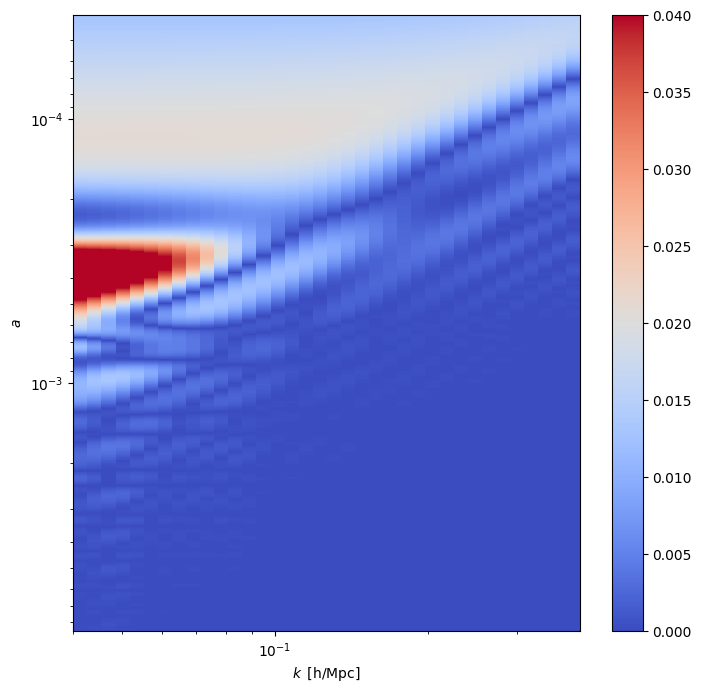

In [14]:
import matplotlib.pyplot as plt

K,T= np.meshgrid(k_new,a_new)
#print(np.shape(K),np.shape(T))
#print(np.shape(kvals))
fig = plt.figure(figsize=(18,8)) 
cs2h = fig.add_subplot(121)

fig_cs2h = cs2h.pcolormesh(K,T,abs(cs2_fid_new-cs2_arb_new),cmap='coolwarm', vmin = 0, vmax = 0.04) #,shading='gouraud')
#rect = patches.Rectangle((kl, al), kr-kl, ar-al, linewidth=1, edgecolor='r', facecolor='none')
#fig_cs2h = cs2h.pcolormesh(K,T,cs2_2d)
#cs2h.add_patch(rect)

# cs2h.set_xlim(kvals[0],kvals[-1])
# cs2h.set_ylim([3.04e-8,1.e0])
cs2h.set_xscale('log')
cs2h.set_yscale('log')
cs2h.set_xlabel(r'$k  \,\,\, \mathrm{[h/Mpc]}$')
cs2h.set_ylabel(r'$a$')
cs2h.invert_yaxis()
fig.colorbar(fig_cs2h)
#+fine_dcs2(2999,1464,10,10,coarse_dcs2(10,10,ij_pairs,vals),'kick')

In [15]:
np.shape(a_new), np.shape(k_new)

((4060,), (36,))

In [16]:
# Read in original Fisher matrix
Fisher_matrix_old = grab_evals(gdmdir,NC,ss,kmin,kmax,amin,amax,cap,lnl)
Fisher_matrix_original = np.diag(Fisher_matrix_old[0:55])

In [ ]:
def compute_jacobian_numerical(phi, a_new, k_new, cs2_fid_arr, ravelsize, kl, kr, al, ar, PC, epsilon):
    n_dot_prod = np.size(PC, 0)
    n_phi = len(phi)
    
    J = np.zeros((n_dot_prod, n_phi))
    
    for i in range(n_phi):
        phi_perturbed = phi.copy()
        phi_perturbed[i] += epsilon[i]
        
        k, a_tau, w_T, w_T_prime, cs2 = get_sound_speeds(*phi_perturbed)
        cs2_new = interpolate_grid(cs2, a_tau, k, a_new, k_new)
        cs2_arr = choose_pixel_mod(ravelsize, kl, kr, al, ar, k_new, a_new, cs2_new)
        cs2_diff = cs2_arr - cs2_fid_arr
        
        dot_prod_perturbed = np.matmul(PC, cs2_diff)
        J[:, i] = dot_prod_perturbed / epsilon[i]
    
    return J

In [18]:
def transform_fisher_matrix(F_orig, J):
    """
    Transform the original Fisher information matrix to new parameters.
    
    Parameters:
        F_orig (numpy array): Original Fisher information matrix (n x n).
        J (numpy array): Jacobian matrix (n x m).
    
    Returns:
        F_new (numpy array): Transformed Fisher information matrix (m x m).
    """
    # Compute the transformed Fisher information matrix
    F_new = J.T @ F_orig @ J  # Resulting shape (m, m)
    return F_new

In [19]:
def invert_fisher_matrix(F):
    """
    Invert the Fisher information matrix.
    
    Parameters:
        F (numpy array): Fisher information matrix (n x n).
    
    Returns:
        F_inv (numpy array): Inverted Fisher information matrix (n x n).
    """
    # Invert the Fisher information matrix
    F_inv = np.linalg.inv(F)
    return F_inv

In [20]:
def error(F_inv):
    """
    Compute the error from the inverted Fisher information matrix.
    
    Parameters:
        F_inv (numpy array): Inverted Fisher information matrix (n x n).
    
    Returns:
        error (numpy array): Error (n x n).
    """
    # Compute the error
    error = np.sqrt(np.diag(F_inv))
    return error

In [21]:
phi = np.array([0.6732117, 0.8, -0.013, 14.3, 0.695])
epsilon = np.array([0.001, 0.1, 0.01, 0.5, 0.1])
J = compute_jacobian_numerical(phi, a_new, k_new, cs2_fid_arr, ravelsize, kl, kr, al, ar, PC[0:55], epsilon)
F_new = transform_fisher_matrix(Fisher_matrix_original, J)

50000000.00000002


Processing Pixels: 100%|██████████| 7913/7913 [00:04<00:00, 1902.81it/s]


[ 0.10672567 -0.11159887 -0.10968129 -0.05019944  0.02284328 -0.12856854
 -0.21323534  0.06787391 -0.05473743  0.04371114  0.0038282   0.03139472
  0.1254737   0.04076973  0.18117837  0.02296658  0.27465802 -0.08847656
 -0.535922    0.00533403  0.02691163 -0.0380193  -0.05371425  0.02585001
 -0.01270585  0.05391776 -0.39614137 -0.02468838 -0.01070557  0.01665637
  0.23388172 -0.03098315  0.15243816  0.08296607 -0.35140605 -0.1471412
  0.11495855  0.60215335 -0.03655845  0.033626   -0.46629935  0.00475643
 -0.73022838 -0.13118137  0.14379861  0.44338341  0.03962079 -0.07097181
  0.49615198 -0.33354579  0.0024304  -0.50744191 -0.03031113  0.0157224
  0.11940139]
49999999.999999985


Processing Pixels: 100%|██████████| 7913/7913 [00:04<00:00, 1730.76it/s]


[-4.33576985e-04  1.72880841e-04  3.09880532e-04 -7.67001137e-05
 -5.90685151e-05  8.65138084e-05  2.78607186e-04  4.02924472e-05
  4.28663746e-05 -1.27363801e-04 -2.84083038e-05  3.06378948e-05
 -2.62896457e-04 -4.90648511e-05 -1.23375355e-03 -2.38859500e-05
 -7.34849203e-04  2.00722273e-04  1.99785196e-03  8.25251193e-04
  3.46412417e-04 -2.38649893e-04  2.02070922e-04  5.34838608e-04
 -4.87291574e-04 -3.59166274e-04  1.13828378e-04  2.29047952e-05
 -9.73907927e-05 -7.23796559e-05 -3.54649988e-04 -4.35516865e-06
 -3.07185974e-04 -2.07148239e-04 -1.80888420e-05  2.26855333e-04
 -2.37504783e-04 -8.51353398e-04  4.82196138e-05 -3.74927190e-07
  2.01081972e-04 -3.06079608e-05  1.00140801e-03  1.09387345e-05
 -1.47684063e-04 -4.58296936e-04  2.74480291e-05  8.04169465e-05
 -2.24049050e-04  3.38613971e-04  5.05968067e-05 -1.99878756e-04
 -4.47324137e-06 -1.60084879e-05 -9.38431983e-05]
50000000.00000002


...

[ 0.02679795 -0.01044361 -0.01865926  0.00466104  0.00239139  0.00125644
 -0.0168421  -0.00260805 -0.00114789  0.0067213   0.00286715 -0.00308007
  0.0167072   0.00223843  0.07913689  0.00099159  0.04930493 -0.01239611
 -0.12770909 -0.05235114 -0.02252837  0.01536657 -0.01253347 -0.03457305
  0.03121722  0.02283255 -0.00691287 -0.00089214  0.0060803   0.0045208
  0.02194551  0.0003011   0.01909194  0.01305808  0.00207381 -0.01398483
  0.01492573  0.05301125 -0.00257813  0.00030076 -0.01113153  0.00188643
 -0.06214913 -0.00021296  0.00923553  0.02671619 -0.00156603 -0.0047068
  0.01197252 -0.02035845 -0.00317347  0.01427965  0.00020926  0.0010694
  0.00590074]
50000000.00000001


Processing Pixels: 100%|██████████| 7913/7913 [00:04<00:00, 1613.62it/s]


[ 2.29027381e-04  2.28854428e-04  1.83554349e-04  7.23828542e-05
  9.81027408e-05  3.10646116e-04 -1.63755995e-04  2.00036084e-04
 -5.73849616e-05 -1.02227222e-04  1.72838004e-04  4.58371633e-06
  2.27744079e-04 -2.01246226e-04 -2.01911919e-03  4.72891872e-05
 -4.89196863e-04 -2.00759434e-04  3.65864231e-03  2.11898916e-03
 -1.85913870e-05 -8.08273346e-04  3.15059376e-04  7.88281136e-04
 -3.53661101e-04 -1.16256629e-04  7.94579135e-04  6.64153448e-05
 -4.98137324e-05 -1.29553042e-04  9.69440905e-05  2.16312161e-05
 -6.04196716e-06 -3.86230739e-04  1.06186978e-03 -1.33843976e-05
 -8.74890332e-05  7.41281590e-05  4.51987854e-05  3.63329646e-06
  1.60715883e-03 -2.38540242e-05 -7.13702788e-05  9.72621181e-05
 -7.24539696e-06 -1.85198022e-03  1.79983917e-05  3.70673719e-05
 -2.14192053e-03  6.66200217e-05  9.81951691e-06  2.45175307e-03
 -3.08179666e-06 -3.84559294e-06 -1.36197469e-05]
50000000.000000015


Processing Pixels: 100%|██████████| 7913/7913 [00:04<00:00, 1709.23it/s]


[ 2.08629170e-02  1.46030069e-02  1.15891885e-02  5.44713015e-03
  1.12561200e-02 -6.62571236e-04 -2.01981465e-03  9.89047604e-03
  6.13653162e-03 -3.12024017e-03  8.20497645e-03 -6.00026389e-03
  1.57858044e-02 -9.02888509e-03 -1.08587691e-01  3.54639596e-03
 -4.13312402e-02 -1.60199166e-02  2.40837208e-01  1.21212427e-01
 -3.82772996e-02 -3.14730904e-02  1.83656212e-02  1.48783776e-02
  7.59940469e-03  1.50459468e-02  1.25979333e-01  3.78553498e-03
 -6.11751093e-03 -1.03737586e-02  7.29102523e-03  2.53390259e-03
  2.69803654e-03 -4.17449637e-02  1.90770823e-01 -7.18016008e-04
  2.33554250e-03  7.17138950e-03  4.00426693e-03 -9.32987112e-04
  2.70845861e-01 -3.33091477e-03 -6.15643357e-03  8.13479245e-03
 -8.57280298e-04 -2.79203195e-01  1.20679291e-04  3.26440127e-03
 -3.00827701e-01  5.40444109e-03  4.74912737e-04  3.10017555e-01
  6.28786317e-05  5.51391007e-04 -1.54249468e-03]


In [ ]:
F_new = transform_fisher_matrix(Fisher_matrix_original, J)
F_new_inv = invert_fisher_matrix(F_new)

In [27]:
error_lamba_CDM = error(F_new_inv)
print('H_0 value:', 0.6732117, 'Error:', error_lamba_CDM[0])
print('Omega_b value:', 0.02238280, 'Error:', error_lamba_CDM[1])
print('Omega_cdm value:', 0.12038, 'Error:', error_lamba_CDM[2])
print('Omega_k value:', 0., 'Error:', error_lamba_CDM[3])
print('Y_He value:', 0.2454006, 'Error:', error_lamba_CDM[4])

H_0 value: 0.6732117 Error: 0.014720638484789349
Omega_b value: 0.0223828 Error: 0.015793297325219103
Omega_cdm value: 0.12038 Error: 0.003517467668572242
Omega_k value: 0.0 Error: 0.5998801674239268
Y_He value: 0.2454006 Error: 2.4953532448729137


In [22]:
from fishchips.cosmo import Observables
import fishchips.util

In [23]:
pars = np.array(['h', 'frac_dmde', 'g_scf', 'm_scf', 'phi_scf_ini',])
centers = np.array([0.6732117, 0.8, -0.013, 14.3, 0.695])
steps = np.array([0.001, 0.1, 0.01, 0.5, 0.1])

obs = Observables(parameters=pars,
                  fiducial=centers,
                  left=centers-steps,
                  right=centers+steps)

['$h$', '$\\frac{dm}{de}$', '$g_{scf}$', '$m_{scf}$', '$\\phi_{scf, ini}$']


(<Figure size 1000x1000 with 25 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$\\frac{dm}{de}$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='$g_{scf}$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='$m_{scf}$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='$h$', ylabel='$\\phi_{scf, ini}$'>,
         <Axes: xlabel='$\\frac{dm}{de}$'>, <Axes: xlabel='$g_{scf}$'>,
         <Axes: xlabel='$m_{scf}$'>, <Axes: xlabel='$\\phi_{scf, ini}$'>]],
       dtype=object))

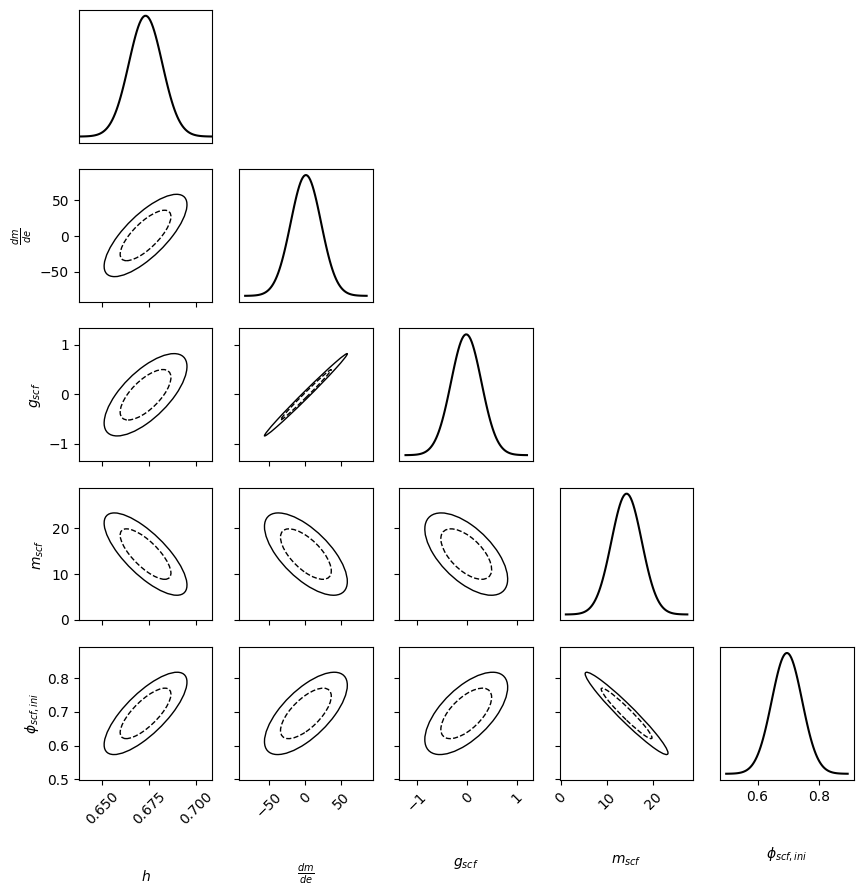

In [24]:
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
cov = np.linalg.inv(F_new)
fishchips.util.plot_triangle(obs, cov, fig, ax, labels = [r'$h$', r'$\frac{dm}{de}$', r'$g_{scf}$', r'$m_{scf}$', r'$\phi_{scf, ini}$'])